# Week 2 - PGM foundations

# Part 1 - The most common continuous model - the Gaussian


Welcome back! Today, we will now focus on how to incorporate continuous variables in your graphical model, and on how to estimate the parameters (e.g. to generate predictions later)


As usual, we'll start with the imports.


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from math import log
%matplotlib inline

One thing we will do a lot in this course, is create some "toy data". The idea is to have datasets that we know so well, that we even know the true parameters. It is important for you to understand how well your PGM is able to learn them!

...of course, in the real world, you don't know the true parameters. That's what makes it hard and interesting!


In [47]:
mu_true = 7  # True parameters. Feel free to mess around with them...
sigma_true = 100
X = np.random.normal(
    mu_true, sigma_true, 1000
)  # generate 1000 samples from this gaussian

It is always useful to plot the distribution, whenever it's possible...


(array([ 2.,  1.,  0.,  0.,  0.,  2.,  3.,  3.,  1.,  5.,  9.,  6.,  6.,
        14., 13., 32., 28., 29., 37., 48., 45., 45., 54., 49., 50., 64.,
        60., 62., 42., 37., 46., 40., 37., 24., 18., 19., 20.,  9., 11.,
         8.,  9.,  7.,  1.,  1.,  0.,  1.,  0.,  0.,  1.,  1.]),
 array([-356.69667499, -342.33309575, -327.9695165 , -313.60593726,
        -299.24235802, -284.87877878, -270.51519953, -256.15162029,
        -241.78804105, -227.42446181, -213.06088256, -198.69730332,
        -184.33372408, -169.97014484, -155.6065656 , -141.24298635,
        -126.87940711, -112.51582787,  -98.15224863,  -83.78866938,
         -69.42509014,  -55.0615109 ,  -40.69793166,  -26.33435241,
         -11.97077317,    2.39280607,   16.75638531,   31.11996455,
          45.4835438 ,   59.84712304,   74.21070228,   88.57428152,
         102.93786077,  117.30144001,  131.66501925,  146.02859849,
         160.39217774,  174.75575698,  189.11933622,  203.48291546,
         217.84649471,  232.21007395

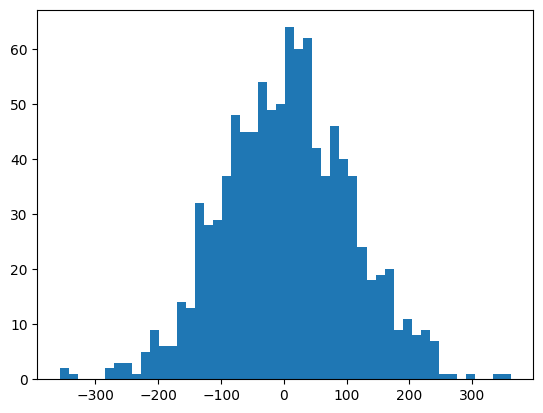

In [48]:
plt.hist(X, bins=50)

## 1.1 Maximum Log Likelihood

So, we're ready to start...


In the last lecture, you played with the log likelihood function:


$ln\text{ }L(\mu, \sigma^2)=-\frac{n}{2}ln(2\pi)-\frac{n}{2}ln(\sigma^2)-\frac{1}{2\sigma^2}\sum_i^N (x_i-\mu)^2$


We still assume that the standard deviation, $\sigma$ is given. The program below finds the (approximate) maximum log likelihood estimate for the mean ($\mu$)


In [49]:
def Gaussian_loglikelihood(X, mu, sigma):
    n = len(X)
    return (
        - n / 2 * log(2 * np.pi)
        - n / 2 * log(sigma**2)
        - 1 / (2 * sigma**2) * sum([(x - mu) ** 2 for x in X])
    )


# Assuming that sigma is given
def MLE(X, sigma):
    l = []
    maxll = -9999999
    bestmu = -9999999
    mus = np.arange(-100, 100, 0.01)
    for mu in mus:
        ll = Gaussian_loglikelihood(X, mu, sigma)
        l.append(ll)
        if ll > maxll:
            bestmu = mu
            maxll = ll
    return bestmu, mus, l

Please test your program (e.g. choose $\sigma=5$)


In [50]:
bestmu, _, l = MLE(X, sigma=5)
print(f"best mu with least error {bestmu}")
print(f"what the hell is the variable l?: {max(l)}")

best mu with least error 4.79000000005361
what the hell is the variable l?: -212572.17211099973


## 1.2. Bayesian model


In this case, the difference in our model is that we also have priors. Since we're only estimating $\mu$, we only need to add that prior. Let's assume it is:

$\mu \sim \mathcal{N}(\alpha, \gamma)$

You can assume that the values of $\alpha$ and $\gamma$ are known (e.g., $\alpha=0$ and $\gamma=50$, thus making this a very uninformative prior).

Our log probability formula then becomes:

$ln\text{ }L(\mu, \sigma, \alpha, \gamma)=-\frac{n}{2}ln(2\pi)-\frac{n}{2}ln(\sigma^2)-\frac{1}{2\sigma^2}\sum_i^N (x_i-\mu)^2-\frac{ln(2\pi)}{2}-\frac{ln(\gamma^2)}{2}-\frac{(\alpha-\mu)^2}{2\gamma^2}$


Essentially, we only added the last three terms to the earlier formula. Can you estimate now the value for $\mu$ (you can reuse the function given above if you want)?

Tip: to see more the effect of the prior more clearly, we will consider just a subset of the data. You should play around with the subset size to see it affects the results.


In [51]:

def Gaussian_loglikelihood_with_prior(X, mu, alpha, gamma, sigma):
    n = len(X)
    return (
        - n / 2 * log(2 * np.pi)
        - n / 2 * log(sigma**2)
        - 1 / (2 * sigma**2) * sum([(x - mu) ** 2 for x in X])
        - log(2 * np.pi) / 2
        - log(gamma**2) / 2
        - ((alpha - mu)**2) / (2 * (gamma ** 2))
    )


# Assuming that sigma is given
def MLE_with_prior(X, sigma, alpha, gamma):
    l = []
    maxll = -9999999
    bestmu = -9999999
    mus = np.arange(-100, 100, 0.01)
    for mu in mus:
        ll = Gaussian_loglikelihood_with_prior(X, mu, alpha, gamma, sigma)
        l.append(ll)
        if ll > maxll:
            bestmu = mu
            maxll = ll
    return bestmu, mus, l

In [52]:
bestmu, mus, likelihood = MLE_with_prior(X, sigma=10,alpha=0, gamma=50)

print(f"best mu with least error when for mu is given {bestmu}")

best mu with least error when for mu is given 4.79000000005361


Can you visualize the log probability, as a function $\mu$?


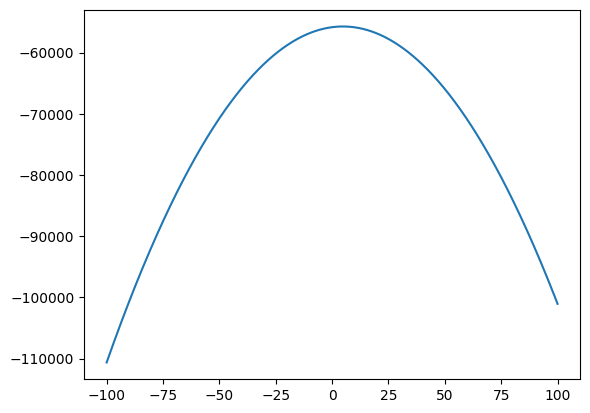

In [53]:
plt.plot(mus, likelihood)

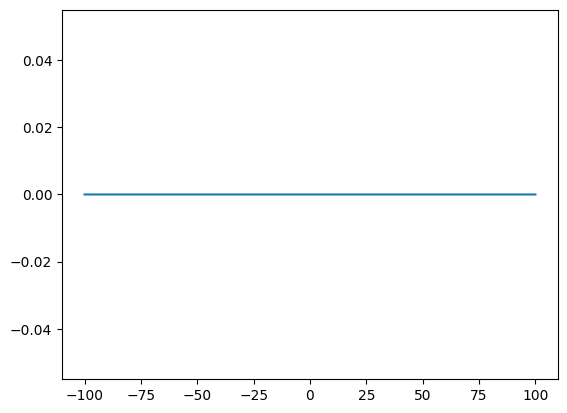

In [54]:
plt.plot(mus, np.exp(likelihood))

Hmmm... the value is not that different, indeed. Why didn't the Bayesian model work better? To answer this, try varying the number of datapoints. The lower it is, the more important your prior becomes!


<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/sm/bpqf8wpj6478c8rtz31k076r0000gn/T/ipykernel_72954/4183306802.py:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("$\mu$")


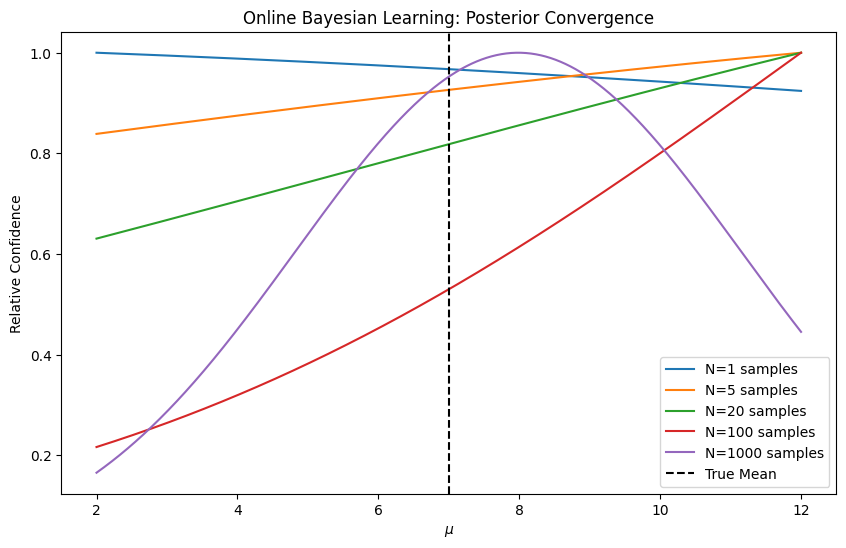

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def plot_online_learning(true_mu, sigma, alpha_prior, gamma_prior, n_steps=[1, 5, 20, 100, 1000]):
    mus = np.linspace(true_mu - 5, true_mu + 5, 1000)
    all_data = np.random.normal(true_mu, sigma, max(n_steps))
    
    plt.figure(figsize=(10, 6))
    
    for n in n_steps:
        X_subset = all_data[:n]
        
        # Calculate log-likelihood for all possible mus
        ll_vals = [Gaussian_loglikelihood_with_prior(X_subset, m, alpha_prior, gamma_prior, sigma) for m in mus]
        
        # Convert to probability space (normalize so the peak is 1 for visual clarity)
        probs = np.exp(ll_vals - np.max(ll_vals)) 
        
        plt.plot(mus, probs, label=f'N={n} samples')

    plt.axvline(true_mu, color='black', linestyle='--', label='True Mean')
    plt.title("Online Bayesian Learning: Posterior Convergence")
    plt.xlabel("$\mu$")
    plt.ylabel("Relative Confidence")
    plt.legend()
    plt.show()

plot_online_learning(7, 100, 0, 50)

Challenge to take home: make it an online learning process (you can even make it a movie! :-) )...


**p.s.: the above may indicate that, after a few datapoints, there is no point in making a Bayesian model. But notice we're here in the 1-dimensional world! If you have a few more dimensions, the amount of necessary data becomes tremendously large (Google "curse of dimensionality")!**


# Part 2 - Generative story


Consider the "dwell time prediction" story we discussed in the lecture.

Implement a function that generates the data according to the slides.

We write the first and last lines of your code... ;-)


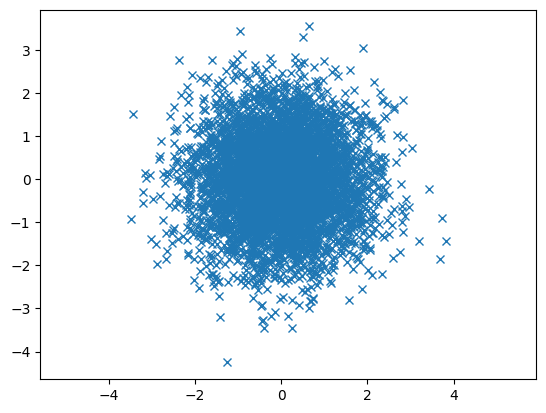

In [56]:
mean = [0,0]
cov = [[1,0], [0,1]]
x, y = np.random.multivariate_normal(mean, cov, 5000).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show()

In [57]:
def dwell_time(X, N, sigmab, sigmae, pi):
    dtn = []
    
    ### BETA 
    
    mean = [0, 0]
    cov = [[sigmab, 0], [0,sigmab]]
    beta_0, beta_1 = np.abs(np.random.multivariate_normal(mean, cov))
    
    ###
    
    for i in range(N):
        kn = np.abs(np.random.normal(beta_0 + beta_1 * X[i], np.sqrt(sigmae)))

        zn = np.random.binomial(1, pi)
        
        if zn == 1:
            dtn.append(kn)
        else:
            dtn.append(0)
        

    return dtn  # returns the list of generated data through ancestral sampling

Let's create the X dataset then


In [58]:
N = 1000
x = np.random.binomial(
    1, 0.4, size=N
)  # there's less occurences of peak hour buses (just because it's less time in the day)

Run your function to generate N points (i.e. perform _ancestral sampling_). Choose whatever parameters you like


In [59]:
dtn = dwell_time(x, N, 5, 1, 0.8)

Do some plots...

(array([214.,  37.,  41.,  42.,  29.,  40.,  37.,  28.,  38.,  33.,  43.,
         43.,  43.,  48.,  39.,  31.,  29.,  29.,  19.,  20.,  24.,  19.,
         13.,  12.,   5.,   9.,  10.,   8.,   3.,   3.,   4.,   3.,   2.,
          0.,   0.,   1.,   0.,   0.,   0.,   1.]),
 array([0.        , 0.14155087, 0.28310174, 0.42465261, 0.56620348,
        0.70775434, 0.84930521, 0.99085608, 1.13240695, 1.27395782,
        1.41550869, 1.55705956, 1.69861043, 1.84016129, 1.98171216,
        2.12326303, 2.2648139 , 2.40636477, 2.54791564, 2.68946651,
        2.83101738, 2.97256825, 3.11411911, 3.25566998, 3.39722085,
        3.53877172, 3.68032259, 3.82187346, 3.96342433, 4.1049752 ,
        4.24652606, 4.38807693, 4.5296278 , 4.67117867, 4.81272954,
        4.95428041, 5.09583128, 5.23738215, 5.37893301, 5.52048388,
        5.66203475]),
 <BarContainer object of 40 artists>)

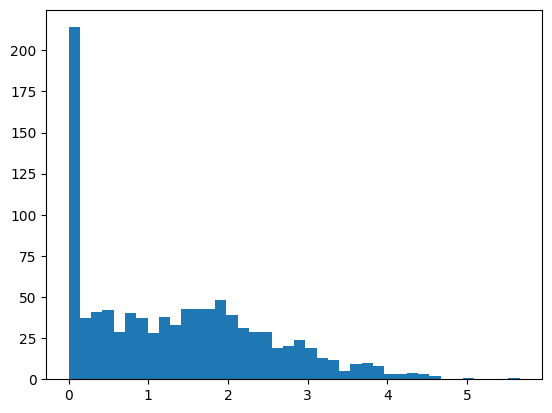

In [60]:
plt.hist(dtn, bins=40)

Did you notice anything strange? In some runs of the ancestral sampling, you will notice that your model generates negative dwell times, which doesn't make sense from the domain perspective! (This is called a prior predictive check.) Why does it generate negative dwell times? Well, it is expectable given the way that the model is specified. Remember, the model encodes your assumptions and domain knowledge. So, you can tweak it accordingly! In this case, how would you modify the model specification above so that it doesn't allow for negative dwell time values? Think about it, implement the changes, re-run ancestral sampling and analyze the results. 